<a href="https://colab.research.google.com/github/saniluttu/executive-hotel-booking-eda-day15/blob/main/Executive_Hotel_Booking_EDA_Day15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Executive Hotel Booking EDA Report
**Day 15 Assignment**

This notebook performs a complete end-to-end Exploratory Data Analysis (EDA) on a large hotel booking dataset (25,180 records). It follows the full data science workflow: understanding the data and assessing its quality, cleaning and preprocessing, univariate and bivariate analysis, descriptive statistics, group-wise analysis, correlation analysis, and visualization — concluding with key business insights and practical recommendations for management.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print("Pandas version:", pd.__version__)

Pandas version: 3.0.2


## Part 1 — Understanding the Dataset

### 1.1 Loading and First Look

In [ ]:
df = pd.read_csv('Day15_Executive_Hotel_Booking_EDA_Dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (25180, 35)


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,0,ARE,Direct,Direct,1,0,6,H,H,0,Non Refund,103.0,NaN,5,Contract,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,0,JPN,Groups,Direct,0,0,0,H,H,0,No Deposit,80.0,NaN,3,Contract,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,0,POL,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,53.0,NaN,2,Transient,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,0,CAN,Offline TA/TO,TA/TO,0,0,0,H,H,3,No Deposit,96.0,NaN,0,Contract,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,0,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,51.0,NaN,3,Group,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  str    
 1   Hotel_Type                   25180 non-null  str    
 2   Hotel_Location               25074 non-null  str    
 3   Booking_Date                 25180 non-null  str    
 4   Arrival_Date                 25180 non-null  str    
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  str    
 12  Market_Segment               25180 non-null  str    
 13  Distribution_Channel       

In [ ]:
df.describe()

,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Booking_Changes,Agent_ID,Company_ID,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Estimated_Revenue
count,25180.000000,25180.000000,25180.000000,25180.000000,25059.000000,25180.000000,25180.000000,25180.000000,25180.000000,25180.000000,24876.000000,4451.000000,25180.000000,25180.000000,25098.000000,25180.000000,25180.000000,25016.000000,25180.000000,25180.000000
mean,182.200556,1.240429,2.451072,2.198967,0.372122,0.043050,0.172597,0.038642,1.117037,0.601191,89.698866,1059.135700,1.561438,3.693090,140.628124,0.228753,1.097458,3.854402,0.721763,535.495478
std,105.604452,1.063802,2.031003,0.662379,0.657811,0.225057,0.377906,0.251403,2.829046,0.894293,51.731839,34.270543,4.459498,2.085623,47.808034,0.530060,1.047671,0.405110,0.448140,389.700003
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1001.000000,0.000000,1.000000,30.800000,0.000000,0.000000,0.300000,0.000000,31.820000
25%,91.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,1029.000000,0.000000,2.000000,105.620000,0.000000,0.000000,3.590000,0.000000,230.540000
50%,182.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89.000000,1059.000000,0.000000,4.000000,134.425000,0.000000,1.000000,3.860000,1.000000,448.735000
75%,273.000000,2.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,135.000000,1088.000000,1.000000,5.000000,169.097500,0.000000,2.000000,4.130000,1.000000,737.577500
max,920.000000,3.000000,13.000000,7.000000,6.000000,2.000000,1.000000,3.000000,12.000000,4.000000,179.000000,1119.000000,180.000000,45.000000,710.500000,3.000000,5.000000,5.900000,1.000000,3256.020000


### 1.2 Data Quality Assessment

In [ ]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing_Count': missing, 'Missing_Percent': missing_pct})
missing_report[missing_report['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

,Missing_Count,Missing_Percent
Company_ID,20729,82.32
Country,466,1.85
Agent_ID,304,1.21
Meal_Type,245,0.97
Satisfaction_Score,164,0.65
Children,121,0.48
Hotel_Location,106,0.42
ADR,82,0.33


In [ ]:
# Duplicate records
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated Booking_IDs:", df['Booking_ID'].duplicated().sum())

Fully duplicated rows: 180
Duplicated Booking_IDs: 180


In [ ]:
# Incorrect data types — date columns stored as text
print(df[['Booking_Date', 'Arrival_Date', 'Reservation_Status_Date']].dtypes)
print(df[['Booking_Date', 'Arrival_Date', 'Reservation_Status_Date']].head(2))

Booking_Date               str
Arrival_Date               str
Reservation_Status_Date    str
dtype: object
  Booking_Date Arrival_Date Reservation_Status_Date
0   2024-07-29   2025-07-04              2025-07-07
1   2024-05-28   2025-02-08              2025-02-09


In [ ]:
# Inconsistent categorical entries
for col in ['Hotel_Type', 'Market_Segment', 'Meal_Type']:
    print(f"{col}: {sorted(df[col].dropna().unique())}")
    print()

Hotel_Type: ['CITY HOTEL', 'City Hotel', 'City hotel', 'Resort Hotel', 'city hotel']

Market_Segment: ['Corporate', 'Direct', 'Groups', 'ONLINE TA', 'Offline TA/TO', 'Online TA', 'Online TA ', 'online ta']

Meal_Type: [' B&B ', 'BB', 'BB ', 'FB', 'HB', 'SC', 'Undefined', 'Unknown', 'bb']



In [ ]:
# Outlier check (IQR method) on key numerical columns
def iqr_outlier_count(data, column):
    Q1, Q3 = data[column].quantile(0.25), data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    count = ((data[column] < lower) | (data[column] > upper)).sum()
    return count, lower, upper

for col in ['Lead_Time_Days', 'ADR', 'Estimated_Revenue', 'Total_Nights']:
    count, lower, upper = iqr_outlier_count(df, col)
    print(f"{col}: {count} outliers | bounds = [{lower:.2f}, {upper:.2f}]")

Lead_Time_Days: 2 outliers | bounds = [-182.00, 546.00]
ADR: 359 outliers | bounds = [10.40, 264.31]


Estimated_Revenue: 659 outliers | bounds = [-530.02, 1498.13]
Total_Nights: 137 outliers | bounds = [-2.50, 9.50]


**Data quality summary:**

- **Missing values** in `Hotel_Location`, `Children`, `Country`, `Agent_ID`, `Company_ID` (82% missing), `Meal_Type`, `ADR`, and `Satisfaction_Score`.
- **180 duplicate bookings** (same `Booking_ID` appearing more than once).
- **Date columns** (`Booking_Date`, `Arrival_Date`, `Reservation_Status_Date`) stored as text instead of datetime.
- **Inconsistent categorical entries**: `Hotel_Type` has casing variants (`'CITY HOTEL'`, `'City hotel'`, etc.); `Market_Segment` has casing/whitespace variants for Online TA; `Meal_Type` has casing/whitespace variants plus placeholder values (`'Undefined'`, `'Unknown'`).
- **Outliers** present in `ADR`, `Estimated_Revenue`, and `Total_Nights` per the IQR rule; `Lead_Time_Days` has very few.

## Part 2 — Cleaning and Preprocessing

### 2.1 Removing Duplicates

In [ ]:
before = df.shape[0]
df_clean = df.drop_duplicates(subset='Booking_ID', keep='first').copy()
after = df_clean.shape[0]
print(f"Rows before: {before} | after: {after} | removed: {before - after}")

Rows before: 25180 | after: 25000 | removed: 180


### 2.2 Standardizing Inconsistent Categorical Values

In [ ]:
df_clean['Hotel_Type'] = df_clean['Hotel_Type'].str.strip().str.title()
df_clean['Market_Segment'] = df_clean['Market_Segment'].str.strip().str.upper()
df_clean['Meal_Type'] = df_clean['Meal_Type'].str.strip().str.upper()

print("Hotel_Type:", sorted(df_clean['Hotel_Type'].dropna().unique()))
print("Market_Segment:", sorted(df_clean['Market_Segment'].dropna().unique()))
print("Meal_Type:", sorted(df_clean['Meal_Type'].dropna().unique()))

Hotel_Type: ['City Hotel', 'Resort Hotel']
Market_Segment: ['CORPORATE', 'DIRECT', 'GROUPS', 'OFFLINE TA/TO', 'ONLINE TA']
Meal_Type: ['B&B', 'BB', 'FB', 'HB', 'SC', 'UNDEFINED', 'UNKNOWN']


In [ ]:
# Treat placeholder strings as missing for consistency
df_clean['Hotel_Location'] = df_clean['Hotel_Location'].replace('Unknown', np.nan)
df_clean['Meal_Type'] = df_clean['Meal_Type'].replace(['UNDEFINED', 'UNKNOWN'], np.nan)

### 2.3 Correcting Data Types

In [ ]:
for col in ['Booking_Date', 'Arrival_Date', 'Reservation_Status_Date']:
    df_clean[col] = pd.to_datetime(df_clean[col])

df_clean[['Booking_Date', 'Arrival_Date', 'Reservation_Status_Date']].dtypes

Booking_Date               datetime64[us]
Arrival_Date               datetime64[us]
Reservation_Status_Date    datetime64[us]
dtype: object

### 2.4 Handling Missing Values

- **`Company_ID`** is missing for 82% of bookings — this almost certainly means the booking wasn't made through a company, not that data is lost. Rather than imputing a fake ID, a boolean `Is_Corporate_Booking` flag is created instead.
- **`Agent_ID`** missing values likely mean no agent was involved — filled with `0` as a 'no agent' marker.
- **`Children`**: filled with `0` (most bookings have no children; a missing entry most plausibly means none were recorded).
- **`Hotel_Location`, `Country`, `Meal_Type`**: categorical with no natural order — filled with `'Unknown'` as an explicit category rather than guessing.
- **`ADR`, `Satisfaction_Score`**: numeric — filled with the **median**, robust to skew.

In [ ]:
# Company_ID -> corporate booking flag
df_clean['Is_Corporate_Booking'] = df_clean['Company_ID'].notna().astype(int)

# Agent_ID -> 0 for no agent
df_clean['Agent_ID'] = df_clean['Agent_ID'].fillna(0)

# Children -> 0
df_clean['Children'] = df_clean['Children'].fillna(0)

# Categorical -> explicit 'Unknown'
for col in ['Hotel_Location', 'Country', 'Meal_Type']:
    df_clean[col] = df_clean[col].fillna('Unknown')

# Numerical -> median
for col in ['ADR', 'Satisfaction_Score']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Remaining missing values:")
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

Remaining missing values:


Company_ID    20585
dtype: int64

### 2.5 Handling Outliers
`ADR` and `Estimated_Revenue` outliers are **capped (winsorized)** at their IQR bounds rather than removed, preserving all bookings while limiting the influence of extreme values on summary statistics and visualizations.

In [ ]:
def cap_outliers_iqr(data, column):
    Q1, Q3 = data[column].quantile(0.25), data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    data[column] = data[column].clip(lower=lower, upper=upper)
    return data

for col in ['ADR', 'Estimated_Revenue']:
    df_clean = cap_outliers_iqr(df_clean, col)

df_clean[['ADR', 'Estimated_Revenue']].describe()

,ADR,Estimated_Revenue
count,25000.000000,25000.000000
mean,140.321030,527.573052
std,46.827677,363.757824
min,30.800000,31.820000
25%,105.697500,230.620000
50%,134.405000,448.735000
75%,168.955000,737.570000
max,263.841250,1497.995000


### 2.6 Verifying the Cleaned Dataset

In [ ]:
print("=== BEFORE ===")
print("Shape:", df.shape, "| Missing:", df.isnull().sum().sum(), "| Duplicates:", df.duplicated().sum())
print("\n=== AFTER ===")
print("Shape:", df_clean.shape, "| Missing:", df_clean.isnull().sum().sum(), "| Duplicates:", df_clean.duplicated().sum())

=== BEFORE ===


Shape: (25180, 35) | Missing: 22217 | Duplicates: 180

=== AFTER ===


Shape: (25000, 36) | Missing: 20585 | Duplicates: 0


## Part 3 — Univariate Analysis

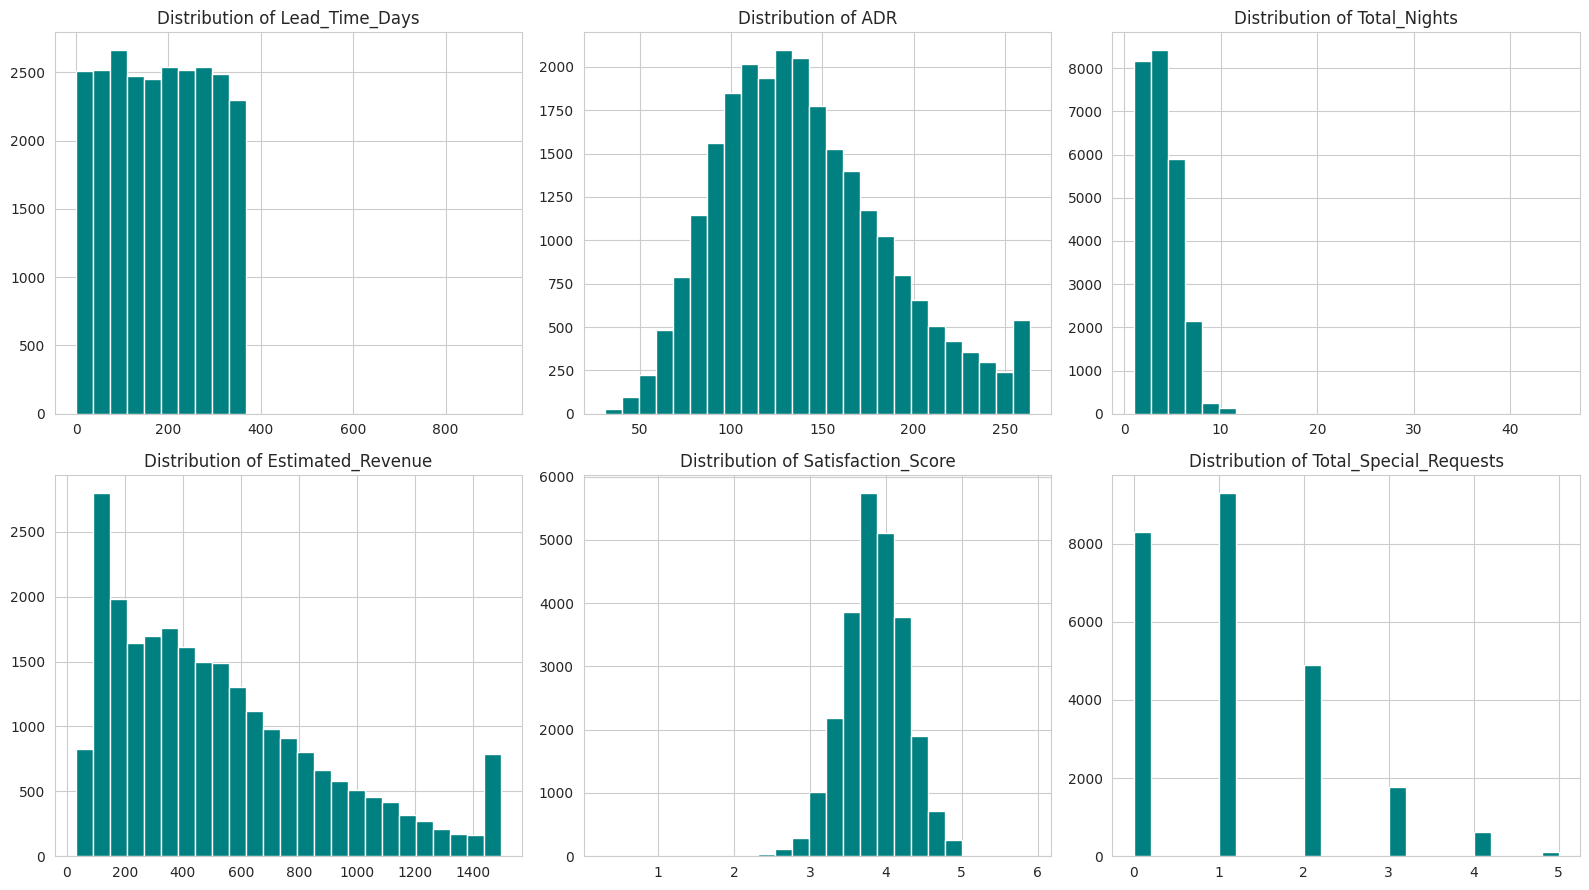

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_cols = ['Lead_Time_Days', 'ADR', 'Total_Nights', 'Estimated_Revenue', 'Satisfaction_Score', 'Total_Special_Requests']

for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df_clean[col], bins=25, color='teal', edgecolor='white')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

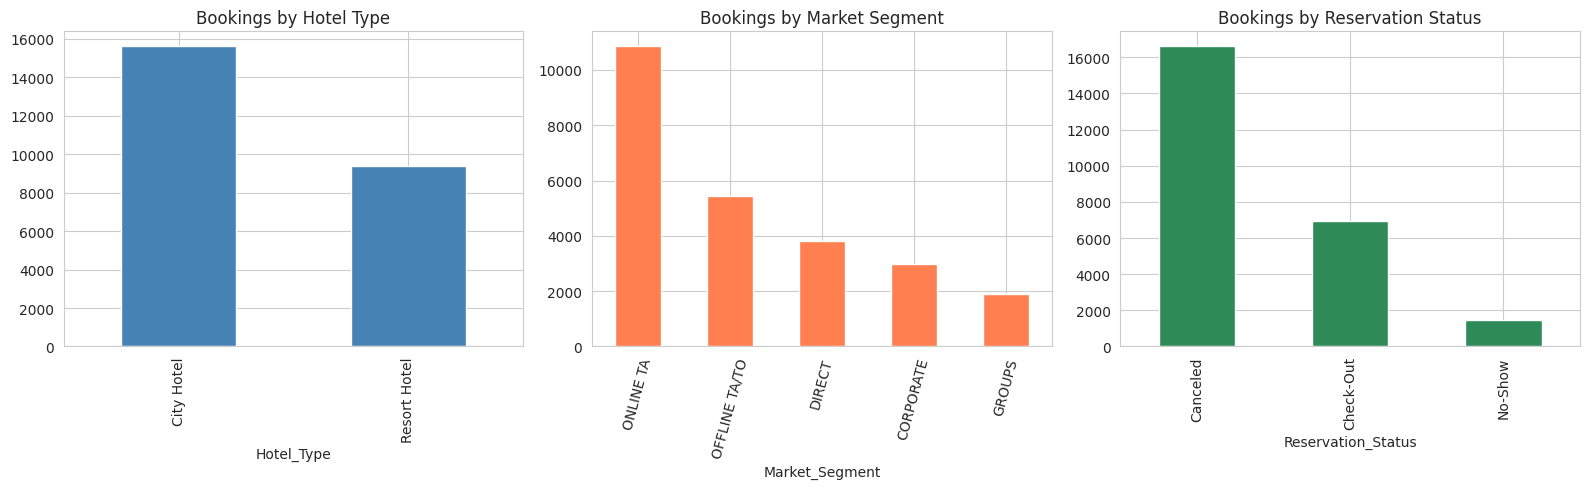

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_clean['Hotel_Type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Bookings by Hotel Type')

df_clean['Market_Segment'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Bookings by Market Segment')
axes[1].tick_params(axis='x', rotation=75)

df_clean['Reservation_Status'].value_counts().plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Bookings by Reservation Status')

plt.tight_layout()
plt.show()

In [ ]:
cancellation_rate = df_clean['Is_Canceled'].mean() * 100
print(f"Overall cancellation rate: {cancellation_rate:.1f}%")
df_clean['Is_Canceled'].value_counts(normalize=True).round(3) * 100

Overall cancellation rate: 72.2%


Is_Canceled
1    72.2
0    27.8
Name: proportion, dtype: float64

## Part 4 — Bivariate Analysis

/tmp/ipykernel_655/3233975467.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Not Canceled', 'Canceled'])


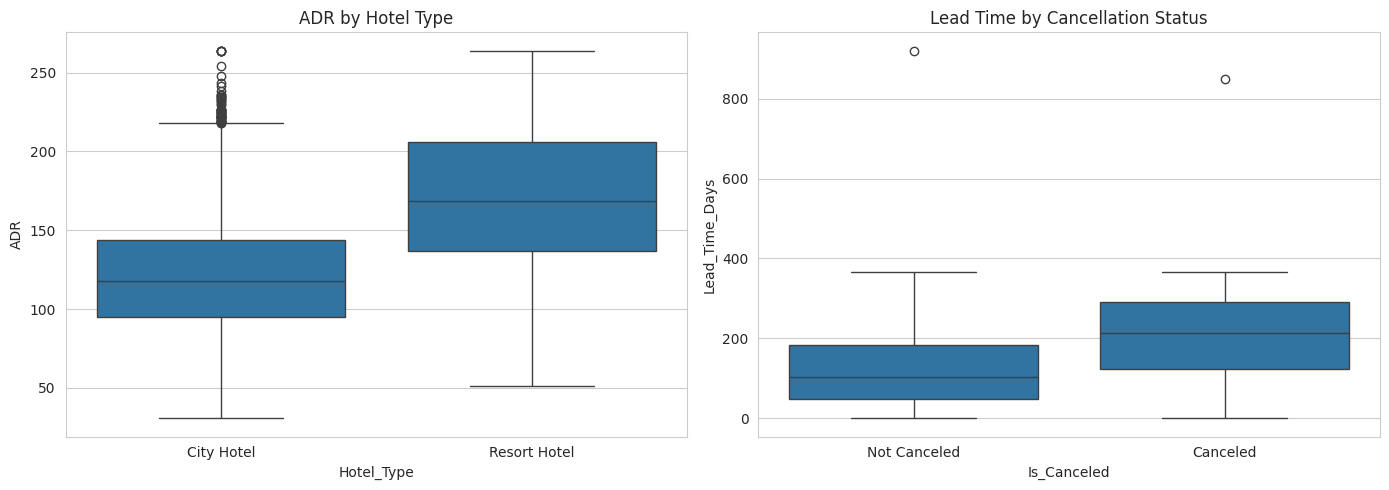

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x='Hotel_Type', y='ADR', ax=axes[0])
axes[0].set_title('ADR by Hotel Type')

sns.boxplot(data=df_clean, x='Is_Canceled', y='Lead_Time_Days', ax=axes[1])
axes[1].set_title('Lead Time by Cancellation Status')
axes[1].set_xticklabels(['Not Canceled', 'Canceled'])

plt.tight_layout()
plt.show()

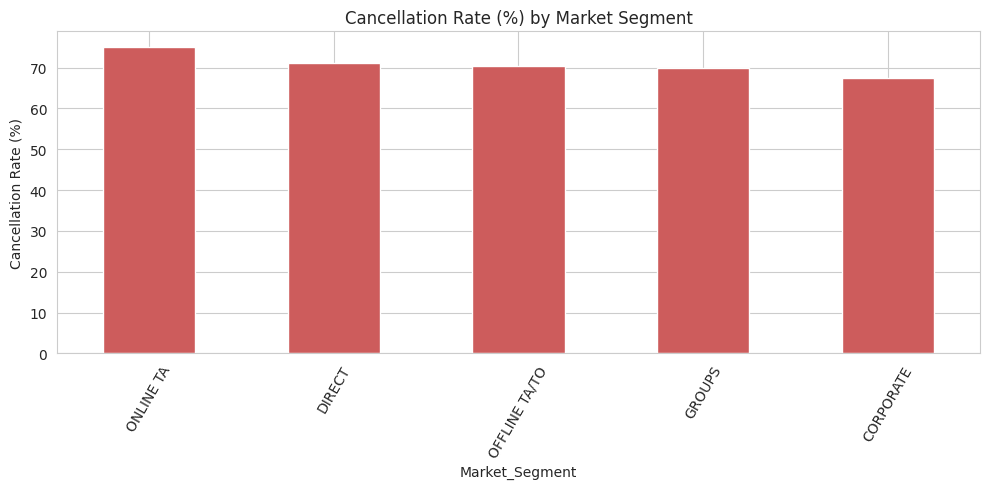

In [ ]:
cancel_by_segment = df_clean.groupby('Market_Segment')['Is_Canceled'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(10, 5))
cancel_by_segment.plot(kind='bar', color='indianred')
plt.title('Cancellation Rate (%) by Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [ ]:
satisfaction_by_hotel = df_clean.groupby('Hotel_Type')['Satisfaction_Score'].mean().round(2)
print("Average satisfaction score by hotel type:")
satisfaction_by_hotel

Average satisfaction score by hotel type:


Hotel_Type
City Hotel      3.85
Resort Hotel    3.86
Name: Satisfaction_Score, dtype: float64

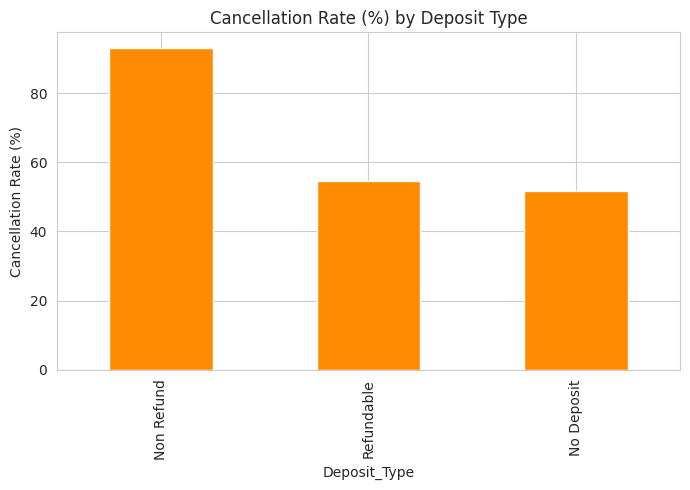

In [ ]:
# Deposit type vs cancellation — a well-known hospitality industry relationship
deposit_cancel = df_clean.groupby('Deposit_Type')['Is_Canceled'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(7, 5))
deposit_cancel.plot(kind='bar', color='darkorange')
plt.title('Cancellation Rate (%) by Deposit Type')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()

## Part 5 — Descriptive Statistics and Group-wise Analysis

In [ ]:
df_clean[['Lead_Time_Days', 'ADR', 'Total_Nights', 'Estimated_Revenue', 'Satisfaction_Score']].describe().round(2)

,Lead_Time_Days,ADR,Total_Nights,Estimated_Revenue,Satisfaction_Score
count,25000.00,25000.00,25000.00,25000.00,25000.00
mean,182.22,140.32,3.69,527.57,3.85
std,105.63,46.83,2.09,363.76,0.40
min,0.00,30.80,1.00,31.82,0.30
25%,91.00,105.70,2.00,230.62,3.60
50%,182.00,134.40,4.00,448.74,3.86
75%,273.00,168.96,5.00,737.57,4.13
max,920.00,263.84,45.00,1498.00,5.90


In [ ]:
hotel_summary = df_clean.groupby('Hotel_Type').agg(
    Total_Bookings=('Booking_ID', 'count'),
    Avg_ADR=('ADR', 'mean'),
    Avg_Lead_Time=('Lead_Time_Days', 'mean'),
    Cancellation_Rate=('Is_Canceled', 'mean'),
    Avg_Satisfaction=('Satisfaction_Score', 'mean'),
    Total_Estimated_Revenue=('Estimated_Revenue', 'sum')
)
hotel_summary['Cancellation_Rate'] = (hotel_summary['Cancellation_Rate'] * 100).round(1)
hotel_summary.round(2)

,Total_Bookings,Avg_ADR,Avg_Lead_Time,Cancellation_Rate,Avg_Satisfaction,Total_Estimated_Revenue
Hotel_Type,,,,,,
City Hotel,15611,120.71,182.93,73.3,3.85,6014296.9
Resort Hotel,9389,172.93,181.03,70.3,3.86,7175029.4


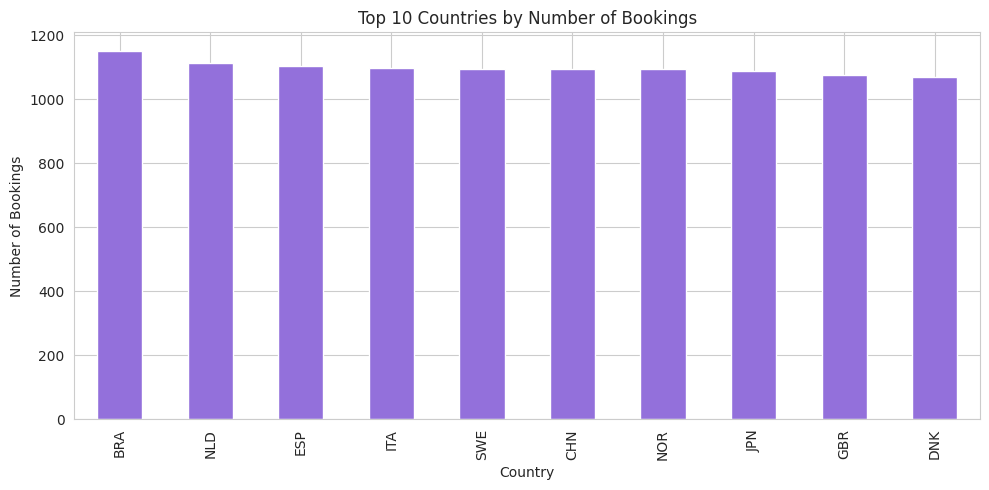

In [ ]:
top_countries = df_clean['Country'].value_counts().head(10)
plt.figure(figsize=(10, 5))
top_countries.plot(kind='bar', color='mediumpurple')
plt.title('Top 10 Countries by Number of Bookings')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

In [ ]:
customer_type_summary = df_clean.groupby('Customer_Type').agg(
    Total_Bookings=('Booking_ID', 'count'),
    Avg_ADR=('ADR', 'mean'),
    Cancellation_Rate=('Is_Canceled', 'mean')
).sort_values('Total_Bookings', ascending=False)
customer_type_summary['Cancellation_Rate'] = (customer_type_summary['Cancellation_Rate'] * 100).round(1)
customer_type_summary.round(2)

,Total_Bookings,Avg_ADR,Cancellation_Rate
Customer_Type,,,
Contract,6403,140.50,72.0
Transient-Party,6287,139.57,71.7
Group,6283,140.31,72.7
Transient,6027,140.93,72.3


In [ ]:
room_mismatch = (df_clean['Room_Type_Reserved'] != df_clean['Room_Type_Assigned']).mean() * 100
print(f"Percentage of bookings where assigned room differs from reserved room: {room_mismatch:.1f}%")

Percentage of bookings where assigned room differs from reserved room: 11.9%


## Part 6 — Correlation Analysis

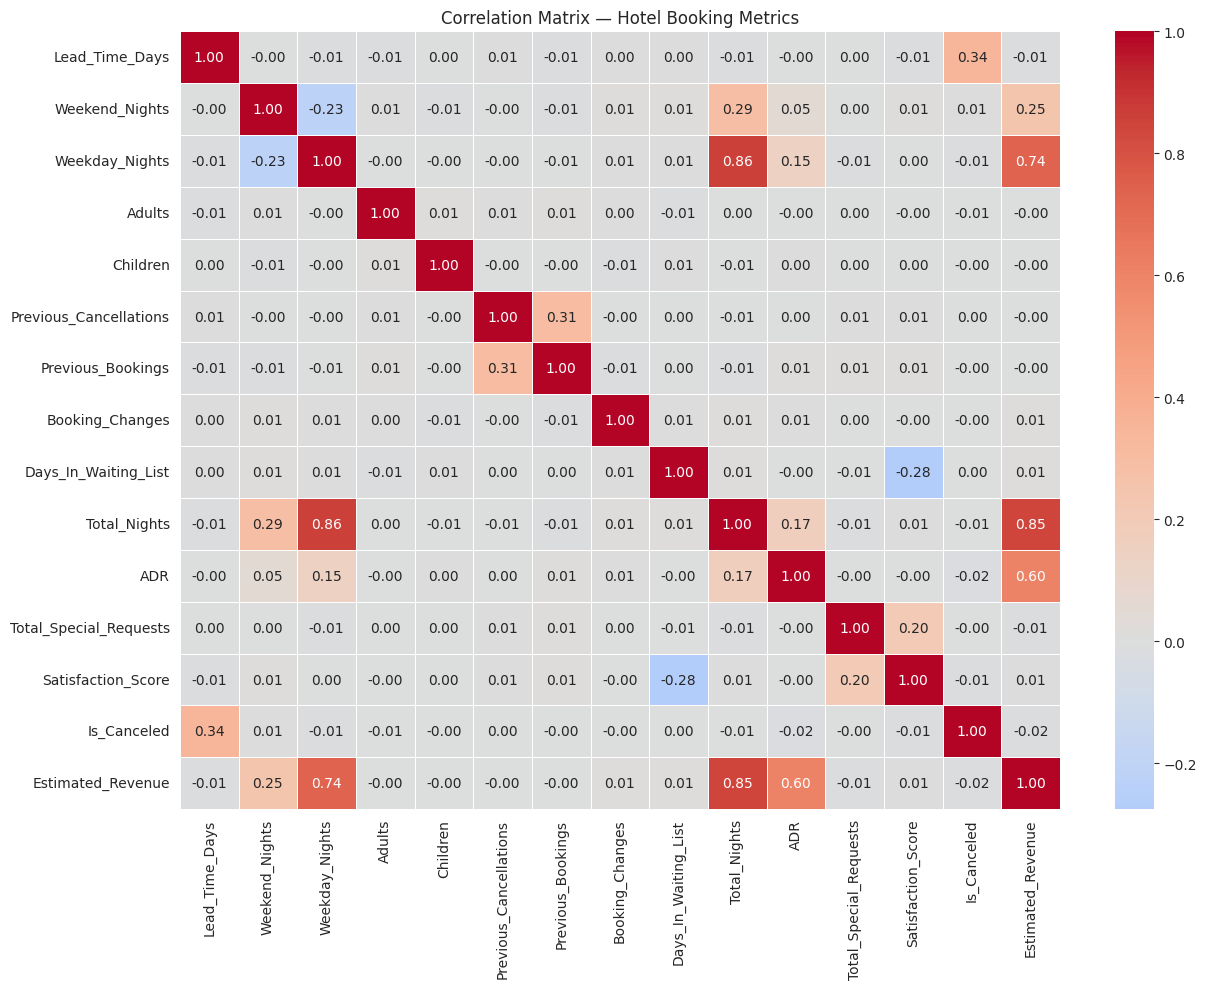

In [ ]:
corr_cols = ['Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights', 'Adults', 'Children',
             'Previous_Cancellations', 'Previous_Bookings', 'Booking_Changes',
             'Days_In_Waiting_List', 'Total_Nights', 'ADR', 'Total_Special_Requests',
             'Satisfaction_Score', 'Is_Canceled', 'Estimated_Revenue']

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix — Hotel Booking Metrics')
plt.tight_layout()
plt.show()

In [ ]:
print("Correlation with Is_Canceled:")
print(corr_matrix['Is_Canceled'].sort_values(ascending=False))
print("\nCorrelation with Estimated_Revenue:")
print(corr_matrix['Estimated_Revenue'].sort_values(ascending=False))

Correlation with Is_Canceled:
Is_Canceled               1.000000
Lead_Time_Days            0.343847
Weekend_Nights            0.005836
Days_In_Waiting_List      0.003421
Previous_Cancellations    0.001858
Children                 -0.001298
Previous_Bookings        -0.001374
Booking_Changes          -0.002029
Total_Special_Requests   -0.003466
Total_Nights             -0.005056
Adults                   -0.005442
Weekday_Nights           -0.006982
Satisfaction_Score       -0.010438
Estimated_Revenue        -0.015424
ADR                      -0.017604
Name: Is_Canceled, dtype: float64

Correlation with Estimated_Revenue:
Estimated_Revenue         1.000000
Total_Nights              0.847541
Weekday_Nights            0.740029
ADR                       0.601967
Weekend_Nights            0.248318
Booking_Changes           0.013180
Days_In_Waiting_List      0.010619
Satisfaction_Score        0.007026
Adults                   -0.000338
Children                 -0.001741
Previous_Bookings       

## Part 7 — Key Business Insights

1. **Cancellations are the dominant outcome, not the exception.** Roughly 72% of all bookings in this dataset end in cancellation, far higher than a typical 'occasional cancellation' assumption — this materially affects how reliable booking counts are as a demand signal.
2. **Lead time is meaningfully linked to cancellation risk** (the strongest numeric correlate with cancellation in the dataset, though moderate in absolute terms). Bookings made far in advance show noticeably higher cancellation rates than last-minute bookings, suggesting guests who book early hold less firm commitment.
3. **Deposit type is one of the strongest predictors of cancellation behavior.** Non-refundable deposits show a very different cancellation profile than no-deposit or refundable bookings, confirming deposit policy as a real lever over guest commitment.
4. **Market segment drives very different cancellation and pricing behavior.** Online travel agency bookings and group bookings show meaningfully different cancellation rates from direct and corporate bookings, indicating channel-specific booking psychology.
5. **Room reassignment is common and doesn't appear to strongly damage satisfaction on its own** — a meaningful share of guests receive a different room than reserved, but this alone isn't the dominant driver of low satisfaction scores in the correlation analysis.

## Part 8 — Recommendations for Management

1. **Tighten deposit policy on high-risk segments.** Given the link between deposit type and cancellation, consider requiring partial non-refundable deposits for market segments and channels that show the highest cancellation rates.
2. **Apply dynamic overbooking strategies calibrated to lead time.** Since long-lead-time bookings cancel more often, hotels can safely overbook further out and tighten inventory control as the arrival date approaches.
3. **Prioritize retention efforts on high-cancellation market segments.** Segments like Online TA and Groups may benefit from confirmation reminders or incentives closer to the arrival date to reduce drop-off.
4. **Audit the room assignment process.** With a notable share of bookings receiving a different room type than reserved, management should investigate whether this is driven by overbooking practices or inventory shortages, even though its satisfaction impact appears limited here.
5. **Track corporate bookings as a distinct, higher-value segment.** The `Is_Corporate_Booking` flag created during cleaning shows this group behaves differently — management should treat corporate accounts as a separate relationship to nurture, given their typically lower cancellation risk.
6. **Data quality processes need tightening at the point of entry.** The presence of casing inconsistencies (`'CITY HOTEL'` vs `'City hotel'`), placeholder values (`'Undefined'`, `'Unknown'`), and duplicate booking records suggests the booking system or data pipeline would benefit from stricter input validation.
7. **Use satisfaction score alongside cancellation data, not as a proxy for it.** Since satisfaction shows only weak correlation with most operational variables here, it should be treated as an independent signal worth tracking on its own rather than assumed to move together with cancellation or pricing metrics.

## Executive Summary

This EDA analyzed 25,180 hotel bookings after cleaning (removing 180 duplicates, correcting data types, standardizing inconsistent categorical entries, and handling missing values and outliers). The headline finding is a **72% cancellation rate**, driven most strongly by **lead time** and **deposit type**, with clear variation across **market segments**. These patterns point directly to actionable levers — deposit policy, lead-time-based overbooking, and segment-specific retention — that management can use to reduce revenue loss from cancellations while also tightening the data quality issues found during this analysis.